In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv('NFLX.csv')

In [3]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200
...,...,...,...,...,...,...,...
5039,2022-05-27,193.190002,195.250000,190.369995,195.190002,195.190002,8586000
5040,2022-05-31,196.179993,199.949997,190.800003,197.440002,197.440002,11398500
5041,2022-06-01,198.699997,202.740005,191.660004,192.910004,192.910004,8416200
5042,2022-06-02,192.020004,205.470001,191.720001,205.089996,205.089996,9623100


In [4]:
df.isnull()

,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
5039,False,False,False,False,False,False,False
5040,False,False,False,False,False,False,False
5041,False,False,False,False,False,False,False
5042,False,False,False,False,False,False,False


In [5]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


In [6]:
sns.set(rc={'figure.figsize':(15,8)})


 Making Date column as index

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


Netflix Volume Traded over year

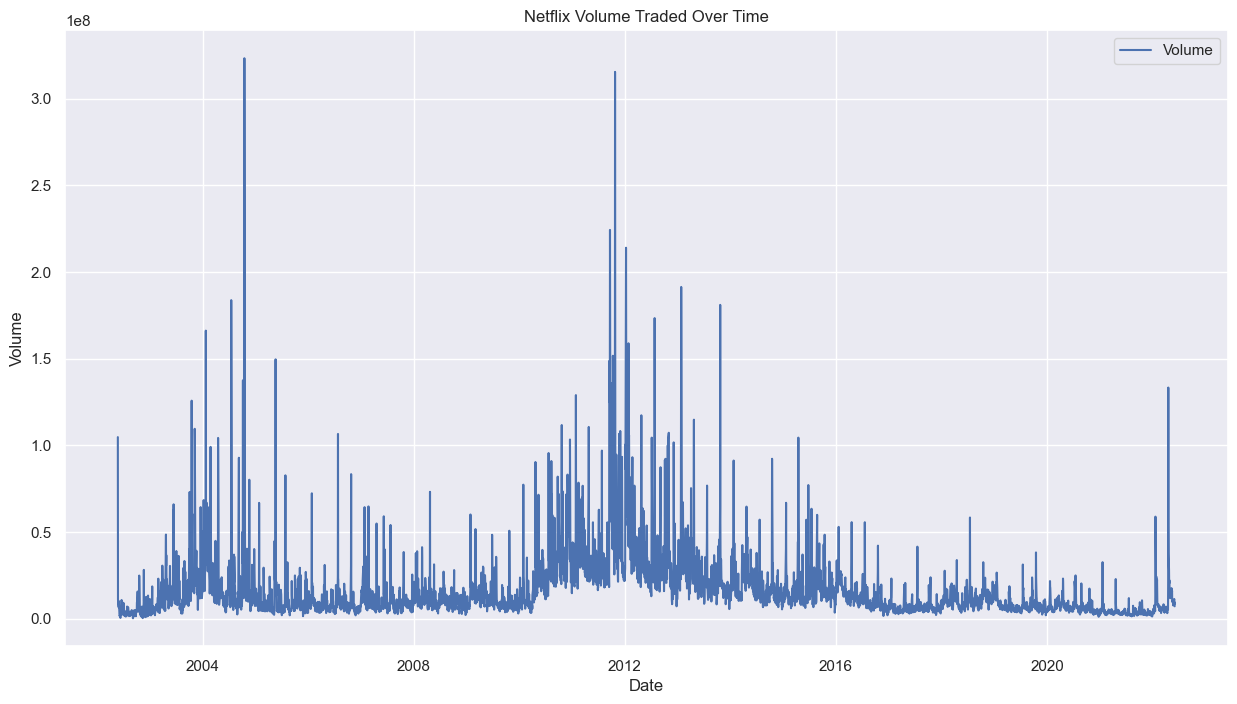

In [8]:
df_reset = df.reset_index()  # makes 'Date' a column again
sns.lineplot(x='Date', y='Volume', data=df_reset, label='Volume')
plt.title('Netflix Volume Traded Over Time')
#plt.xticks(rotation=45)
plt.show()


Netflix Stock Price - High,Open,Close

<Axes: title={'center': 'Netflix Open and Close Prices Over Time'}, xlabel='Date'>

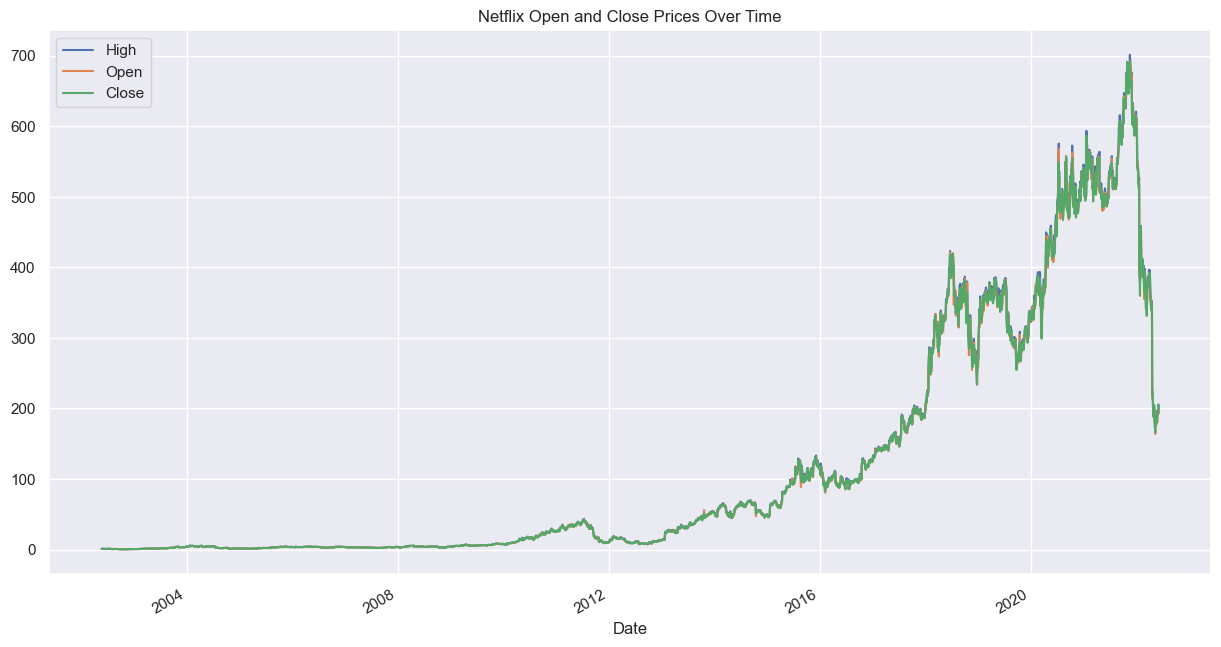

In [9]:
df.plot(x='Date', y=['High','Open', 'Close'], title='Netflix Open and Close Prices Over Time')


Netflix Stock Price-Day ,Month,Year

In [10]:
df['Date'] = pd.to_datetime(df['Date'])  # convert Date column to datetime
df = df.set_index('Date')                # set it as index


<Axes: title={'center': 'Average Volume by Year'}, xlabel='Year'>

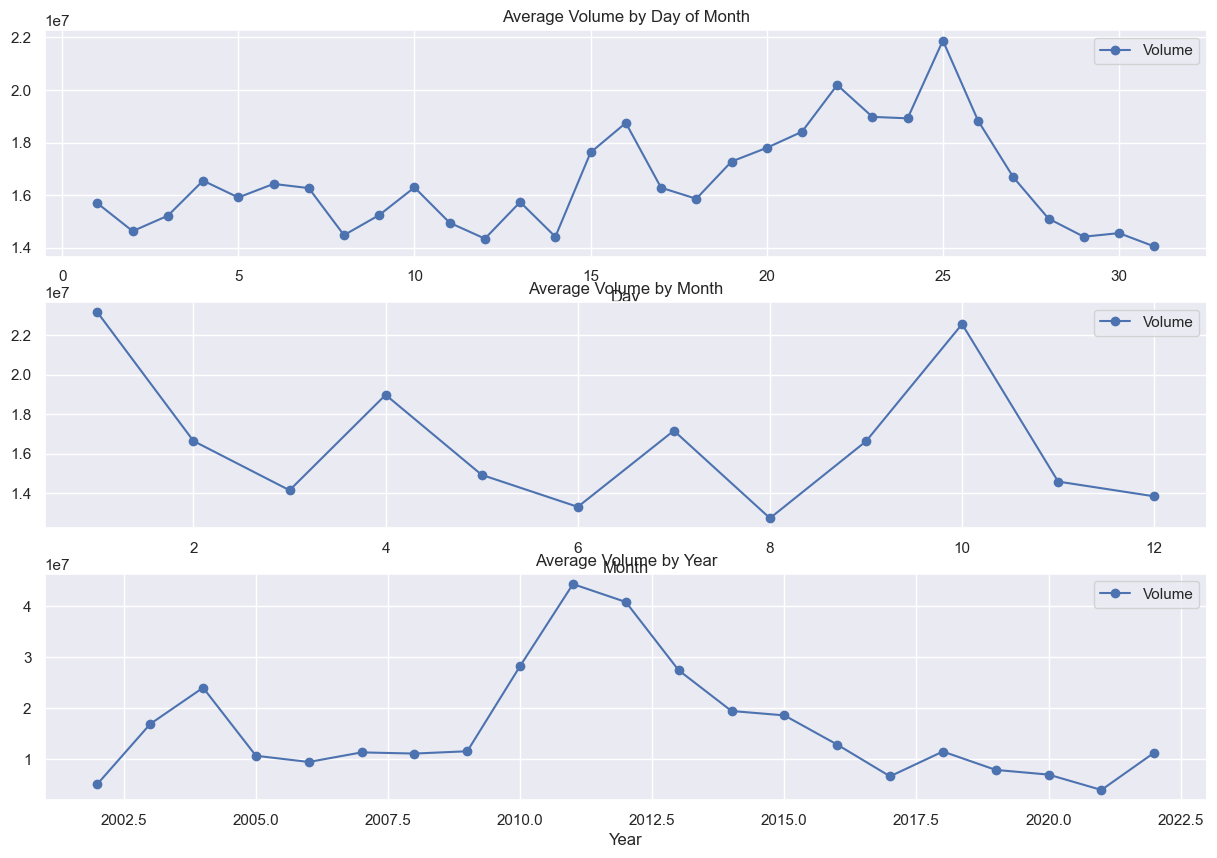

In [11]:
fig,(ax1,ax2,ax3 ) = plt.subplots(3, figsize=(15,10))
df.groupby(df.index.day).mean().plot(y="Volume", ax=ax1, title='Average Volume by Day of Month',marker='o',xlabel = "Day")
df.groupby(df.index.month).mean().plot(y="Volume", ax=ax2, title='Average Volume by Month',marker='o',xlabel = "Month")
df.groupby(df.index.year).mean().plot(y ='Volume',ax =ax3, title='Average Volume by Year',marker='o',xlabel = "Year")


Top-5 Dates with highest Stock price

In [12]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200
...,...,...,...,...,...,...
2022-05-27,193.190002,195.250000,190.369995,195.190002,195.190002,8586000
2022-05-31,196.179993,199.949997,190.800003,197.440002,197.440002,11398500
2022-06-01,198.699997,202.740005,191.660004,192.910004,192.910004,8416200


In [13]:
a = df.sort_values(by='High' , ascending=False).head(5)
a['High']

Date
2021-11-17    700.989990
2021-11-19    694.159973
2021-11-18    691.739990
2021-10-29    690.969971
2021-11-01    689.969971
Name: High, dtype: float64

In [14]:
b = df.sort_values(by='Low' , ascending=True).head(5)
b['Low']

Date
2002-10-10    0.346429
2002-10-09    0.347143
2002-10-07    0.382143
2002-10-08    0.390714
2002-10-16    0.442857
Name: Low, dtype: float64

Text(0.5, 1.0, 'Low Prices')

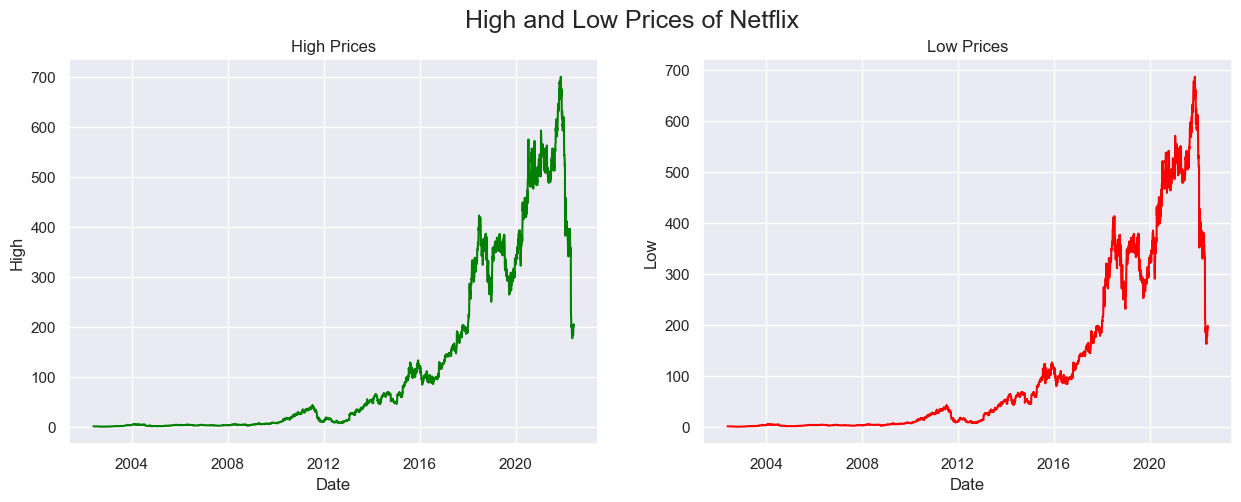

In [15]:
fig,axes=plt.subplots(nrows=1,ncols=2,sharex=True,figsize=(15,5))
fig.suptitle('High and Low Prices of Netflix',fontsize=18)
sns.lineplot(ax = axes[0],y = df['High'],x=df.index,color='green').set_title('High Prices')
sns.lineplot(ax = axes[1],y = df['Low'],x=df.index,color='red').set_title('Low Prices')